# Stopping time simulations

In [4]:
# imports
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

from helpers.sample import make_sample, stopping_time

In [5]:
theta = 0.05
N = 5000
alpha = 0.05
beta = 0.95
B = 500

stopping_times = []
for _ in range(B):
  sample = make_sample(N, theta)
  _, st = stopping_time(sample, alpha, beta)
  stopping_times.append(st)

KeyboardInterrupt: 

In [64]:
average_stopping_time = np.mean(stopping_times)
print(f"Average stopping time: {average_stopping_time / N}")
print(f"Upper bound stopping time: {(scipy.stats.norm.ppf(1-alpha) + scipy.stats.norm.ppf(beta)) / (theta * np.sqrt(N))}")

Average stopping time: 0.709842
Upper bound stopping time: 0.9304697229413388


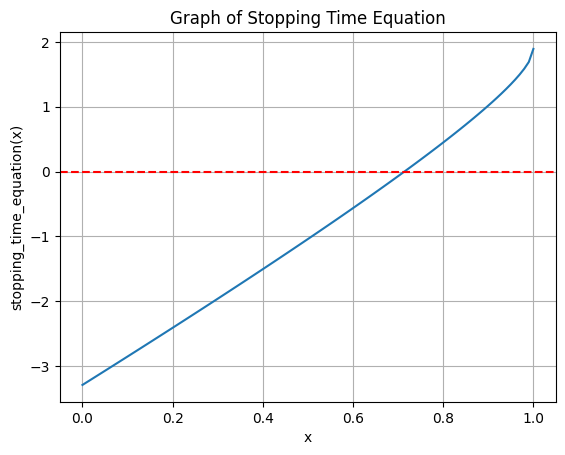

Root of stopping time equation: 0.7140262466145941


In [65]:
# set up root finding problem with equation
# equation: theta * sqrt{N} * x = z_{1-alpha} + z_beta*sqrt(1 - x)
def stopping_time_equation(x):
  return theta * np.sqrt(N) * x - (scipy.stats.norm.ppf(1-alpha) + scipy.stats.norm.ppf(beta) * np.sqrt(1 - x))

# graph function
x = np.linspace(0, 1, 100)
y = stopping_time_equation(x)
plt.plot(x, y)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('stopping_time_equation(x)')
plt.title('Graph of Stopping Time Equation')
plt.grid()
plt.show()

# find root of equation
from scipy.optimize import root_scalar
result = root_scalar(stopping_time_equation, bracket=[0, 1], method='bisect')
print(f"Root of stopping time equation: {result.root}")

## Simulation results

In [6]:
# load data/relative_gap_summary.csv
relative_gap_summary = pd.read_csv(ROOT / "data/relative_gap_summary.csv")
print(relative_gap_summary)

     theta      N  alpha  beta  mean_value  sd_value  mean_stopping_time  \
0      0.0   1000   0.01  0.80    0.029601  0.966515             997.950   
1      0.0   1000   0.01  0.90   -0.045985  1.011638             998.658   
2      0.0   1000   0.01  0.95   -0.083270  0.968994             999.890   
3      0.0   1000   0.01  0.99    0.016674  0.963289             999.766   
4      0.0   1000   0.05  0.80   -0.087517  0.925753             987.890   
..     ...    ...    ...   ...         ...       ...                 ...   
155    1.0  50000   0.01  0.99    0.990100  0.000077            1036.518   
156    1.0  50000   0.05  0.80    0.801043  0.000821             555.832   
157    1.0  50000   0.05  0.90    0.900696  0.000532             652.514   
158    1.0  50000   0.05  0.95    0.950407  0.000318             733.254   
159    1.0  50000   0.05  0.99    0.990112  0.000087             884.602   

     sd_stopping_time  mean_stopping_fraction  sd_stopping_fraction  \
0           21.9

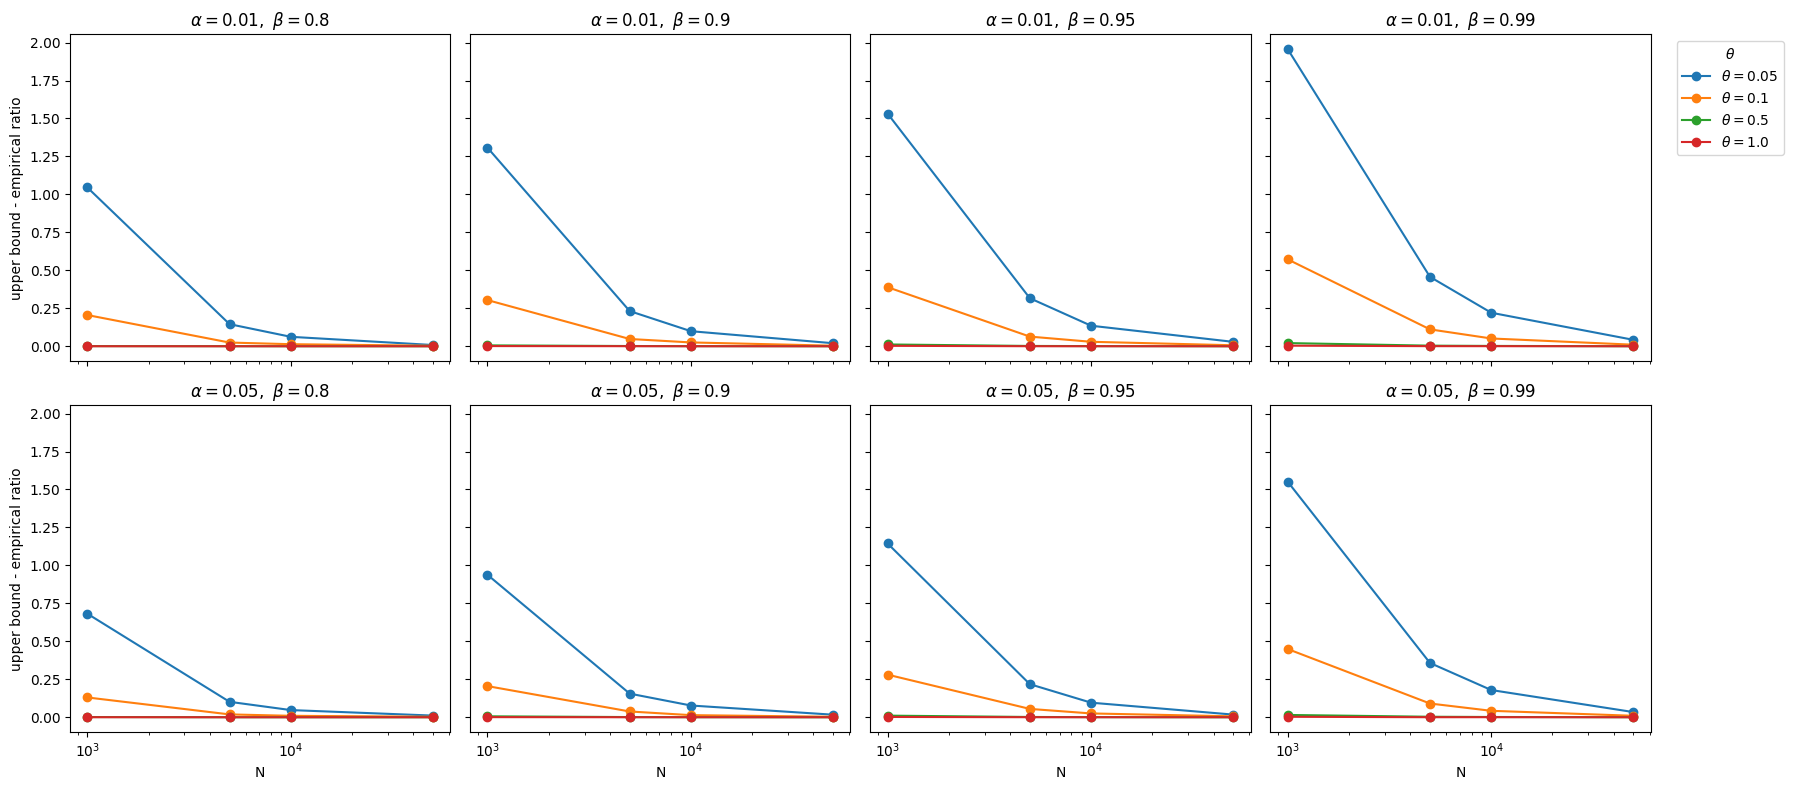

In [18]:
df = relative_gap_summary.query("theta > 0").copy()

df["absolute_gap"] = (
    df["upper_bound_fraction"]
    - df["mean_stopping_fraction"]
)

df = df.sort_values(["alpha", "beta", "theta", "N"])

alphas = sorted(df["alpha"].unique())
betas = sorted(df["beta"].unique())

fig, axes = plt.subplots(
    len(alphas),
    len(betas),
    figsize=(4.5 * len(betas), 4 * len(alphas)),
    sharex=True,
    sharey=True,
)

if len(alphas) == 1 and len(betas) == 1:
    axes = [[axes]]
elif len(alphas) == 1:
    axes = [axes]
elif len(betas) == 1:
    axes = [[ax] for ax in axes]

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i][j]

        data_combo = df[
            (df["alpha"] == alpha)
            & (df["beta"] == beta)
        ]

        for theta, data_theta in data_combo.groupby("theta"):
            data_theta = data_theta.sort_values("N")

            ax.plot(
                data_theta["N"],
                data_theta["absolute_gap"],
                marker="o",
                label=fr"$\theta={theta}$",
            )

        ax.set_xscale("log")
        ax.set_title(fr"$\alpha={alpha},\ \beta={beta}$")

        if i == len(alphas) - 1:
            ax.set_xlabel("N")

        if j == 0:
            ax.set_ylabel("upper bound - empirical ratio")

        if i == 0 and j == len(betas) - 1:
            ax.legend(title=r"$\theta$", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    "../plots/stopping_time_ub.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()